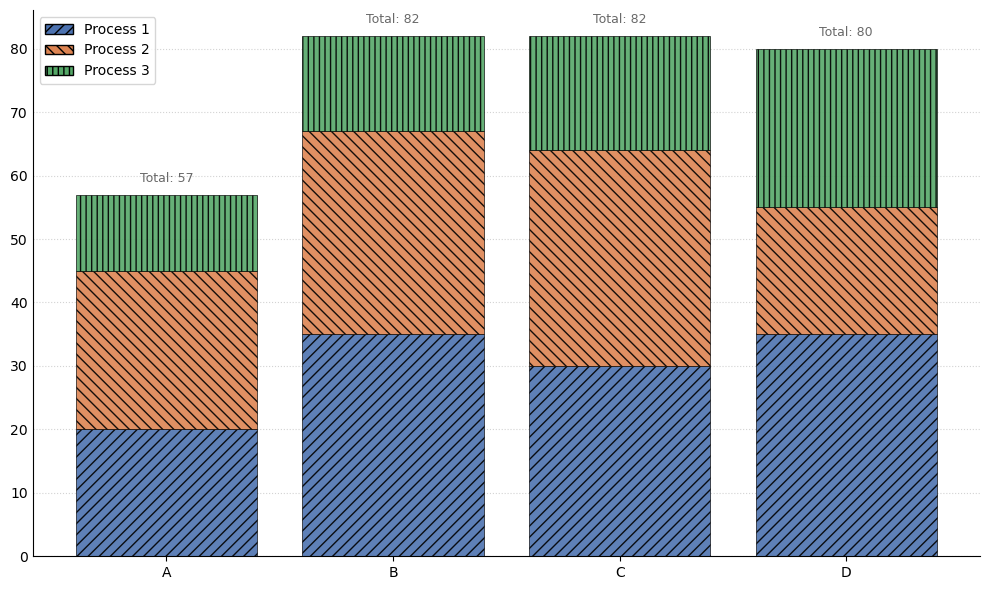

In [3]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
categories = ['A', 'B', 'C', 'D']
series1 = [20, 35, 30, 35]
series2 = [25, 32, 34, 20]
series3 = [12, 15, 18, 25]

# 自定义填充样式和颜色
style_config = [
    {'color': '#4C72B0', 'hatch': '///', 'label': 'Process 1'},
    {'color': '#DD8452', 'hatch': '\\\\\\', 'label': 'Process 2'}, 
    {'color': '#55A868', 'hatch': '|||', 'label': 'Process 3'}
]

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制堆叠柱状图
bottom = np.zeros(len(categories))
for i, config in enumerate(style_config):
    values = [series1, series2, series3][i]
    ax.bar(categories, values, bottom=bottom, 
           color=config['color'], hatch=config['hatch'],
           edgecolor='black', linewidth=0.5, alpha=0.9,
           label=config['label'])
    bottom += np.array(values)

# 创建自定义图例
legend_elements = [
    Patch(facecolor=cfg['color'], hatch=cfg['hatch'], 
          edgecolor='black', label=cfg['label']) 
    for cfg in style_config
]
ax.legend(handles=legend_elements, fontsize=10)

# 添加总数值
totals = bottom
for i, total in enumerate(totals):
    ax.text(i, total + 2, f'Total: {total:.0f}', 
            ha='center', fontsize=9, color='dimgrey')

# 高级样式设置
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_tick_params(length=0)
ax.set_axisbelow(True)
ax.grid(axis='y', color='lightgrey', linestyle=':')

plt.tight_layout()
plt.savefig('堆叠柱状图-自定义背景填充.png', dpi=400, bbox_inches='tight')
plt.show()